# Classificação de Garantido ou Caprichoso com Redes Neurais Convolucionais (CNN)


## 1. Ideia

Criaremos um modelo capaz de identificar torcedores do Caprichoso e Garantido. Para isso, utilizaremos imagens de torcedores de ambos os bois extraídas da internet. Para o treinamento do modelo classificador, será utilizada uma Rede Neural Convolucional (CNN), adequada para a classificação de imagens.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path

print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


## 2. Localizando o dataset

O dataset usado nos notebooks de referência possui 2 pastas, uma para cada boi. Lembre de ajustar o caminho para as pastas, se necessário.

Estrutura esperada:
```text
que_boi_eh_teu/
├── garantido/
├── caprichoso/


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_DIR = Path("/content/drive/MyDrive/que_boi_eh_teu")

if not DATA_DIR.exists():
    print("Ajuste DATA_DIR")
else:
    print("Dataset encontrado em:", DATA_DIR)


Dataset encontrado em: /content/drive/MyDrive/que_boi_eh_teu


## 3. Classes do problema — nomes em português

- `CLASS_NAMES`: nomes reais das pastas, usados para localizar os arquivos;
- `CLASS_NAMES_PT`: nomes das classes ajustados para exibição.


In [ ]:
CLASS_NAMES = [
    "garantido", "caprichoso"
]

CLASS_NAMES_PT = [
    "Garantido", "Caprichoso"
]

for i, (pasta, nome) in enumerate(zip(CLASS_NAMES, CLASS_NAMES_PT)):
    print(f"{i}: {pasta:20s} -> {nome}")

0: garantido            -> Garantido
1: caprichoso           -> Caprichoso


## 4. Criando treino, validação e teste

Vamos dividir o conjunto de imagens em três partes, cada uma com uma finalidade diferente:

- **Treino (70%):** usado para treinar o modelo e ajustar os pesos da rede neural.
- **Validação (15%):** usado durante o treinamento para acompanhar o desempenho do modelo em imagens que não estão sendo utilizadas para ajustar os pesos.
- **Teste (15%):** permanece separado durante todo o treinamento e é utilizado somente ao final para avaliar o desempenho do modelo em dados não vistos.

In [ ]:
import tensorflow as tf
from pathlib import Path
import random

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

random.seed(SEED)

# Listas que armazenarão os caminhos das imagens e seus rótulos
arquivos_treino, rotulos_treino = [], []
arquivos_validacao, rotulos_validacao = [], []
arquivos_teste, rotulos_teste = [], []

for indice_classe, nome_classe in enumerate(CLASS_NAMES):

    pasta_classe = Path(DATA_DIR) / nome_classe

    # Seleciona apenas arquivos de imagem
    arquivos = [
        arquivo for arquivo in pasta_classe.iterdir()
        if arquivo.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]

    # Embaralha as imagens
    random.shuffle(arquivos)

    total = len(arquivos)

    n_treino = int(total * 0.70)
    n_validacao = int(total * 0.15)

    # Divide as imagens da classe
    treino = arquivos[:n_treino]

    validacao = arquivos[
        n_treino:n_treino + n_validacao
    ]

    teste = arquivos[
        n_treino + n_validacao:
    ]

    # Adiciona imagens e seus respectivos rótulos
    arquivos_treino.extend(map(str, treino))
    rotulos_treino.extend([indice_classe] * len(treino))

    arquivos_validacao.extend(map(str, validacao))
    rotulos_validacao.extend([indice_classe] * len(validacao))

    arquivos_teste.extend(map(str, teste))
    rotulos_teste.extend([indice_classe] * len(teste))

def carregar_imagem(caminho, rotulo):

    imagem = tf.io.read_file(caminho)

    imagem = tf.image.decode_image(
        imagem,
        channels=3,
        expand_animations=False
    )

    imagem = tf.image.resize(
        imagem,
        IMG_SIZE
    )

    imagem.set_shape(
        [IMG_SIZE[0], IMG_SIZE[1], 3]
    )

    return imagem, rotulo


def criar_dataset(arquivos, rotulos, embaralhar=False):

    ds = tf.data.Dataset.from_tensor_slices(
        (arquivos, rotulos)
    )

    if embaralhar:
        ds = ds.shuffle(
            len(arquivos),
            seed=SEED
        )

    ds = ds.map(
        carregar_imagem,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.batch(BATCH_SIZE)

    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


train_ds = criar_dataset(
    arquivos_treino,
    rotulos_treino,
    embaralhar=True
)

val_ds = criar_dataset(
    arquivos_validacao,
    rotulos_validacao
)

test_ds = criar_dataset(
    arquivos_teste,
    rotulos_teste
)


total = (
    len(arquivos_treino)
    + len(arquivos_validacao)
    + len(arquivos_teste)
)

print(f"Total de imagens: {total}")
print()
print(f"Treino:     {len(arquivos_treino)} imagens")
print(f"Validação:  {len(arquivos_validacao)} imagens")
print(f"Teste:      {len(arquivos_teste)} imagens")

Total de imagens: 112

Treino:     78 imagens
Validação:  16 imagens
Teste:      18 imagens


## 5. Visualizando as imagens

Antes de treinar qualquer modelo, devemos olhar os dados. Observe variações de iluminação, fundo, posição e tamanho das fotos.


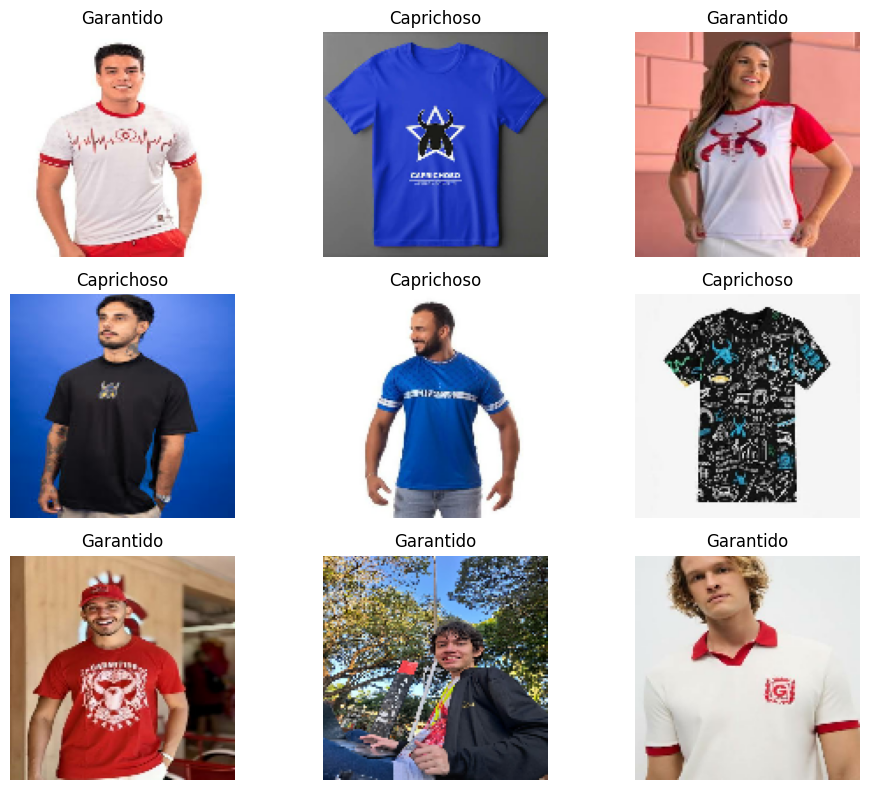

In [ ]:
plt.figure(figsize=(10, 8))
for imagens, rotulos in train_ds.take(1):
    for i in range(min(9, len(imagens))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(imagens[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES_PT[int(rotulos[i])])
        plt.axis("off")
plt.tight_layout()


## 6. Construindo a CNN

A CNN aprenderá características progressivamente:

`Imagem → Conv2D → MaxPooling → Conv2D → MaxPooling → Conv2D → MaxPooling → Flatten → Dense → Softmax`

- **Conv2D:** aprende filtros que detectam padrões visuais.
- **MaxPooling2D:** reduz as dimensões espaciais mantendo características importantes.
- **Flatten:** transforma os mapas de características em um vetor.
- **Dense:** combina as características aprendidas para realizar a classificação.
- **Softmax:** produz uma probabilidade para cada uma das 2 classes.


In [ ]:
from tensorflow.keras import layers, models

data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
])

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    # Aumentação somente durante o treinamento
    data_augmentation,

    # Normalização
    layers.Rescaling(1./255),

    # Extração de características
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    # Classificação
    layers.Flatten(),
    layers.Dense(128, activation="relu"),

    #layers.Dropout(0.4),

    layers.Dense(2, activation="sigmoid")
])

## 7. Compilando o modelo

Como os rótulos são números inteiros (`0` e `1`), usaremos `sparse_categorical_crossentropy`. O otimizador Adam ajustará os pesos da rede. A métrica `accuracy` mede a proporção de classificações corretas.


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### 8. Treinamento

Cada **época** corresponde a uma passagem pelo conjunto de treinamento. O `EarlyStopping` interrompe o treinamento quando a perda de validação deixa de melhorar, restaurando os melhores pesos encontrados.


In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.5513 - loss: 1.2599 - val_accuracy: 0.5000 - val_loss: 0.8159
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.6923 - loss: 0.6485 - val_accuracy: 0.8125 - val_loss: 0.5518
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.8846 - loss: 0.4617 - val_accuracy: 0.8125 - val_loss: 0.3374
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 830ms/step - accuracy: 0.8590 - loss: 0.3310 - val_accuracy: 0.8125 - val_loss: 0.2327
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9103 - loss: 0.2239 - val_accuracy: 0.9375 - val_loss: 0.1577
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 824ms/step - accuracy: 0.9359 - loss: 0.1648 - val_accuracy: 0.8750 - val_loss: 0.1651
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 892ms/step - accuracy: 0.9359 - loss: 0.1403 - val_accuracy: 1.0000 - val_loss: 0.0646
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 840ms/step - accuracy: 0.9487 - loss: 0.1546 - val_accuracy: 1.0000 - val_loss: 0.0595
Epo

## 9. O modelo está aprendendo ou apenas decorando?

Compare as curvas de treino e validação. Se a acurácia de treino continuar aumentando enquanto a validação piora, pode haver **overfitting**.


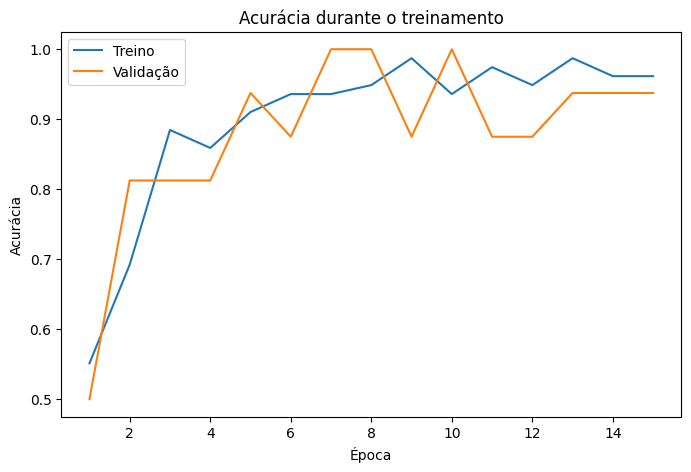

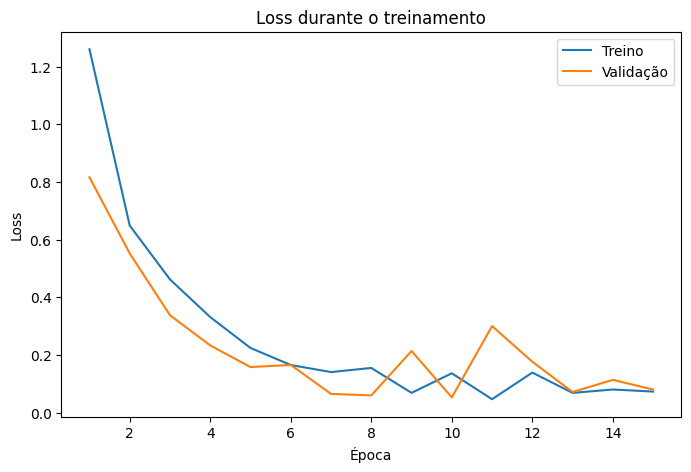

In [ ]:
history_dict = history.history
epocas = range(1, len(history_dict["loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epocas, history_dict["accuracy"], label="Treino")
plt.plot(epocas, history_dict["val_accuracy"], label="Validação")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.title("Acurácia durante o treinamento")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epocas, history_dict["loss"], label="Treino")
plt.plot(epocas, history_dict["val_loss"], label="Validação")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Loss durante o treinamento")
plt.legend()
plt.show()


## 12. Avaliação final no conjunto de teste

Somente agora usamos o conjunto de teste. Ele representa imagens que não foram utilizadas para ajustar os pesos nem para decidir quando parar o treinamento.


In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
print(f"Loss no teste: {test_loss:.4f}")
print(f"Acurácia no teste: {test_accuracy:.2%}")


Loss no teste: 0.1022
Acurácia no teste: 94.44%


## 10. Testando algumas previsões

A saída da `softmax` possui 2 valores. O maior valor indica a classe escolhida pelo modelo. Também podemos apresentar esse valor como **confiança da previsão**.


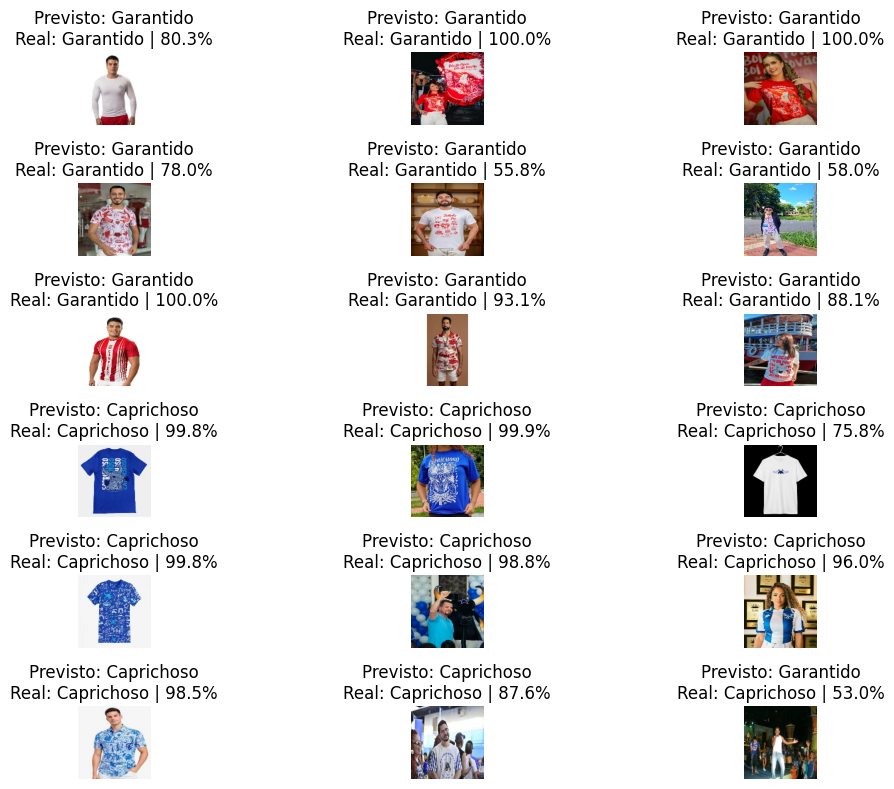

In [ ]:
for imagens, rotulos in test_ds.take(1):
    probabilidades = model.predict(imagens, verbose=0)

plt.figure(figsize=(12, 8))
for i in range(min(18, len(imagens))):
    pred = int(np.argmax(probabilidades[i]))
    confianca = float(np.max(probabilidades[i]))
    real = int(rotulos[i])

    ax = plt.subplot(6, 3, i + 1)
    plt.imshow(imagens[i].numpy().astype("uint8"))
    plt.title(
        f"Previsto: {CLASS_NAMES_PT[pred]}\n"
        f"Real: {CLASS_NAMES_PT[real]} | {confianca:.1%}"
    )
    plt.axis("off")
plt.tight_layout()


## 11. Testando uma imagem escolhida por você

Altere `CAMINHO_IMAGEM` para uma fotografia externa ao dataset. Esse é um teste mais próximo do uso real.


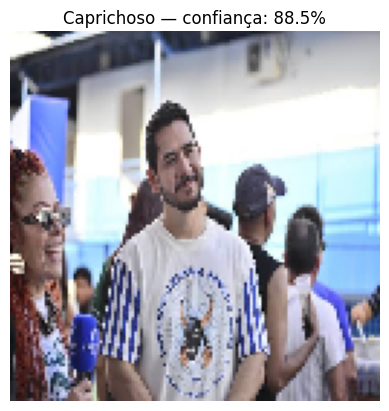

Probabilidades:
caprichoso          : 88.47%
garantido           : 26.48%


In [ ]:
CAMINHO_IMAGEM = "/content/drive/MyDrive/teste/cae.jpg"

img = keras.utils.load_img(CAMINHO_IMAGEM, target_size=IMG_SIZE)
img_array = keras.utils.img_to_array(img)
img_batch = tf.expand_dims(img_array, 0)

probs = model.predict(img_batch, verbose=0)[0]
classe = int(np.argmax(probs))

plt.imshow(img)
plt.axis("off")
plt.title(f"{CLASS_NAMES_PT[classe]} — confiança: {probs[classe]:.1%}")
plt.show()

print("Probabilidades:")
for nome, p in sorted(zip(CLASS_NAMES, probs), key=lambda x: x[1], reverse=True):
    print(f"{nome:20s}: {p:.2%}")


## 12. Salvando o modelo Keras

O arquivo `.keras` preserva o modelo para carregá-lo novamente em Python.


In [ ]:
model.save("modelo_que_boi_eh_teu.keras")
print("Modelo salvo em modelo_que_boi_eh_teu.keras")

# Exemplo de carregamento:
modelo_carregado = keras.models.load_model("modelo_que_boi_eh_teu.keras")
print("Modelo carregado com sucesso!")


Modelo salvo em modelo_que_boi_eh_teu.keras
Modelo carregado com sucesso!


# 📱 Parte 2 — Preparando o modelo para dispositivos móveis

No celular, não precisamos levar o ambiente Python nem treinar novamente. O aplicativo precisa apenas executar **inferência**.

Fluxo:

`Treinamento no Python → modelo Keras → conversão para TFLite → arquivo .tflite → aplicativo React Native → foto → previsão`

Como a camada `Rescaling(1./255)` está dentro do próprio modelo, o app deve fornecer pixels no mesmo formato de entrada esperado pelo modelo; a normalização é realizada pelo modelo.


## 13. Converter Keras para TensorFlow Lite / LiteRT

O formato `.tflite` é apropriado para execução local em dispositivos móveis.


In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("modelo_que_boi_eh_teu.tflite", "wb") as f:
    f.write(tflite_model)

print("Modelo mobile salvo em modelo_que_boi_eh_teu.tflite")


Saved artifact at '/tmp/tmpsfpmtkhv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  136953761493072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136953761491536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136953761495568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136953761495760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136953761492880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136953761486736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136953759654608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136953759661328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136953759648464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136953759661520: TensorSpec(shape=(), dtype=tf.resource, name=None)
Modelo mobile sa

## 14. Conferindo o modelo TFLite ainda no Python

Antes de levar o arquivo para o aplicativo, podemos conferir o formato de entrada e saída.


In [ ]:
interpreter = tf.lite.Interpreter(model_path="modelo_que_boi_eh_teu.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Entrada:", input_details[0]["shape"], input_details[0]["dtype"])
print("Saída:", output_details[0]["shape"], output_details[0]["dtype"])


Entrada: [  1 128 128   3] <class 'numpy.float32'>
Saída: [1 2] <class 'numpy.float32'>


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 15. Teste de inferência com o arquivo `.tflite`

O objetivo desta etapa é confirmar que o modelo convertido continua produzindo previsões antes de integrá-lo ao React Native.


In [ ]:
img = keras.utils.load_img(CAMINHO_IMAGEM, target_size=IMG_SIZE)
entrada = keras.utils.img_to_array(img).astype(np.float32)
entrada = np.expand_dims(entrada, axis=0)

interpreter.set_tensor(input_details[0]["index"], entrada)
interpreter.invoke()
saida = interpreter.get_tensor(output_details[0]["index"])[0]

classe = int(np.argmax(saida))
print("Classe:", CLASS_NAMES_PT[classe])
print(f"Confiança: {saida[classe]:.2%}")


Classe: Caprichoso
Confiança: 88.47%
